## Environment Setup

Clone the project repository, install Unsloth, and verify GPU availability with `nvidia-smi`.

In [1]:
# @title
# @no-extract
!git clone https://github.com/ybakhan/llm-finetuning-uml-antipatterns

!pip install unsloth
!nvidia-smi

fatal: destination path 'llm-finetuning-uml-antipatterns' already exists and is not an empty directory.
Fri May 29 08:39:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                   

## GPU Verification

Confirm CUDA is available and print the GPU device name to ensure the runtime has an accelerator.

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


## Sync Repository

Pull the latest commits from the already-cloned repo so subsequent cells use up-to-date code and data.

In [3]:
# @title
# @no-extract
!cd /content/llm-finetuning-uml-antipatterns && git pull

Already up to date.


## Dataset Overview

Load `samples.yaml` from the generation run and print summary statistics: total sample count, antipattern vs. refactored split, domain count, size distribution (small/medium), and antipattern instance frequency.

In [4]:
# @title
# @no-extract
yaml_path = "/content/llm-finetuning-uml-antipatterns/output/run_20260325_012118/samples.yaml"

import yaml
import pandas as pd

with open(yaml_path) as f:
    samples = yaml.safe_load(f)

df = pd.DataFrame(samples)

# Quick overview
print(f"Total samples: {len(df)}")
print(f"\nSample type distribution:\n{df['sample_type'].value_counts()}")
print(f"\nDomain count: {df['domain_id'].nunique()}")
print(f"\nSize distribution:\n{df['size'].value_counts()}")
print(f"\nAntipattern instance counts:\n{df['total_antipattern_instances'].value_counts()}")

Total samples: 388

Sample type distribution:
sample_type
antipattern    194
refactored     194
Name: count, dtype: int64

Domain count: 194

Size distribution:
size
medium    218
small     170
Name: count, dtype: int64

Antipattern instance counts:
total_antipattern_instances
0    194
1     94
3     44
2     37
4     17
5      2
Name: count, dtype: int64


## Train / Test Split

Load the JSONL dataset and perform a **domain-level** 80/20 split — all samples for a domain land in the same partition — to prevent domain leakage between train and test.

In [5]:
# @title
from datasets import load_dataset
from sklearn.model_selection import train_test_split

jsonl_path = "/content/llm-finetuning-uml-antipatterns/output/run_20260325_012118/samples.jsonl"
dataset = load_dataset("json", data_files=jsonl_path, split="train")

# Split domains
domain_ids = list(set(dataset['domain_id']))
train_domains, test_domains = train_test_split(domain_ids, test_size=0.2, random_state=42)

train_domains_set = set(train_domains)
test_domains_set = set(test_domains)

train_dataset = dataset.filter(lambda x: x['domain_id'] in train_domains_set)
test_dataset = dataset.filter(lambda x: x['domain_id'] in test_domains_set)

print(f"Train: {len(train_dataset)}")
print(f"Test:  {len(test_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/388 [00:00<?, ? examples/s]

Filter:   0%|          | 0/388 [00:00<?, ? examples/s]

Train: 310
Test:  78


## Split Audit

Print every sample ID and its domain assignment for both partitions, then assert that no domain appears in both train and test (zero overlap check).

In [6]:
# @title
# @no-extract
print("=== Train ===")
for i in range(len(train_dataset)):
    print(f"  {train_dataset[i]['sample_id']} → domain {train_dataset[i]['domain_id']}")

print(f"\n=== Test ===")
for i in range(len(test_dataset)):
    print(f"  {test_dataset[i]['sample_id']} → domain {test_dataset[i]['domain_id']}")

# Verify no domain leaks
train_domain_set = set(train_dataset['domain_id'])
test_domain_set = set(test_dataset['domain_id'])
overlap = train_domain_set & test_domain_set
print(f"\nTrain domains: {len(train_domain_set)}")
print(f"Test domains:  {len(test_domain_set)}")
print(f"Domain overlap: {len(overlap)}")
if overlap:
    print(f"  PROBLEM — shared domains: {overlap}")
else:
    print("  Clean — no domain appears in both splits")

=== Train ===
  001_ap_20260325_012118 → domain 1
  001_re_20260325_012118 → domain 1
  002_ap_20260325_012118 → domain 2
  002_re_20260325_012118 → domain 2
  003_ap_20260325_012118 → domain 3
  003_re_20260325_012118 → domain 3
  004_ap_20260325_012118 → domain 4
  004_re_20260325_012118 → domain 4
  005_ap_20260325_012118 → domain 5
  005_re_20260325_012118 → domain 5
  006_ap_20260325_012118 → domain 6
  006_re_20260325_012118 → domain 6
  007_ap_20260325_012118 → domain 7
  007_re_20260325_012118 → domain 7
  008_ap_20260325_012118 → domain 8
  008_re_20260325_012118 → domain 8
  009_ap_20260325_012118 → domain 9
  009_re_20260325_012118 → domain 9
  011_ap_20260325_012118 → domain 11
  011_re_20260325_012118 → domain 11
  012_ap_20260325_012118 → domain 12
  012_re_20260325_012118 → domain 12
  013_ap_20260325_012118 → domain 13
  013_re_20260325_012118 → domain 13
  014_ap_20260325_012118 → domain 14
  014_re_20260325_012118 → domain 14
  015_ap_20260325_012118 → domain 15
  015

## Load Base Model

Download and load `Qwen2.5-Coder-3B-Instruct-bnb-4bit` in 4-bit quantisation via Unsloth's `FastLanguageModel`. The 4-bit NF4 weights reduce VRAM from ~6 GB to ~2 GB with minimal quality loss.

In [7]:
# @title

from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-Coder-3B-Instruct-bnb-4bit",
    max_seq_length=2048,
    load_in_4bit=True,
)

print("Model loaded successfully")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Model loaded successfully


## Configure LoRA Adapters

Attach LoRA adapters (rank `r=8`, scaling `α=16`, dropout `0.1`) to all attention and MLP projection layers. Only ~0.48 % of parameters are trainable, keeping fine-tuning fast and memory-efficient.

In [8]:
# @title

# setup LoRA parameters
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)

print("LoRA adapters configured")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.5.8 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA adapters configured


## Precision Detection

Detect whether the GPU supports bfloat16 (preferred on Ampere+). Sets `bf16`/`fp16` flags used by the trainer so the correct mixed-precision path is taken automatically.

In [9]:
import torch

# Auto-detect precision based on GPU
use_bf16 = torch.cuda.is_bf16_supported()
use_fp16 = not use_bf16

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using bf16: {use_bf16} | fp16: {use_fp16}")

GPU: NVIDIA A100-SXM4-80GB
Using bf16: True | fp16: False


## Fine-Tune

Apply the chat template to each training sample, then run supervised fine-tuning with `SFTTrainer`: 6 epochs, learning rate 5e-5, effective batch size 8 (batch 1 × gradient accumulation 8), with per-epoch checkpointing.

In [10]:
# @title
from trl import SFTTrainer
from transformers import TrainingArguments

def format_sample(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False
    )
    return {"text": text}

train_formatted = train_dataset.map(format_sample)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_formatted,
    dataset_text_field="text",
    args=TrainingArguments(
        output_dir="/content/output_v2",
        num_train_epochs=6,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=5e-5,
        warmup_steps=6,
        weight_decay=0.01,
        logging_steps=5,
        save_strategy="epoch",
        seed=42,
        fp16=use_fp16,
        bf16=use_bf16,
    ),
)

trainer.train()

Map:   0%|          | 0/310 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/310 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 310 | Num Epochs = 6 | Total steps = 234
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,966,784 of 3,100,905,472 (0.48% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.252135
10,1.201233
15,1.145399
20,0.962089
25,0.786138
30,0.610791
35,0.481180
40,0.390678
45,0.329869
50,0.288333


Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-39/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-78/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-117/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-156/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-195/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/output_v2/checkpoint-234/tokenizer_config.json.


TrainOutput(global_step=234, training_loss=0.3050343623528114, metrics={'train_runtime': 866.2747, 'train_samples_per_second': 2.147, 'train_steps_per_second': 0.27, 'total_flos': 1.7991851372494848e+16, 'train_loss': 0.3050343623528114, 'epoch': 6.0})

## Plot Training Loss

Extract per-step loss values from the trainer's log history and render a publication-quality loss curve, annotating epoch boundaries with dashed vertical lines.

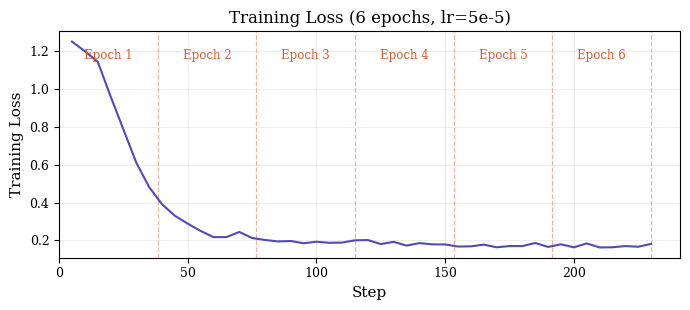

In [12]:
# @title
# @no-extract
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

logs = trainer.state.log_history

steps  = [l["step"] for l in logs if "loss" in l]
losses = [l["loss"] for l in logs if "loss" in l]

NUM_EPOCHS = 6
# Fix: use the actual final step number, not the count of log entries
steps_per_epoch = steps[-1] / NUM_EPOCHS

plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(figsize=(7, 3.2))

ax.plot(steps, losses, color='#534AB7', linewidth=1.5, zorder=3)

y_label = max(losses) * 0.97   # near top, inside axes

for epoch in range(1, NUM_EPOCHS + 1):
    boundary = epoch * steps_per_epoch
    ax.axvline(x=boundary, color='#D85A30', linestyle='--',
               alpha=0.45, linewidth=0.9, zorder=2)
    # Place label at mid-span so labels never overlap each other
    mid = boundary - steps_per_epoch * 0.5
    ax.text(mid, y_label, f'Epoch {epoch}',
            ha='center', va='top', fontsize=8.5, color='#D85A30')

ax.set_xlabel('Step')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss (6 epochs, lr=5e-5)')
ax.grid(True, which='major', alpha=0.25, linewidth=0.6)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('/content/finetune_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()


## Save Adapter

Write the trained LoRA adapter weights and tokenizer to `/content/trained_adapter` for later inference or export.

In [13]:
# @title
# Save the trained adapter
model.save_pretrained("/content/trained_adapter")
tokenizer.save_pretrained("/content/trained_adapter")

print("Adapter saved")

Unsloth: Restored added_tokens_decoder metadata in /content/trained_adapter/tokenizer_config.json.


Adapter saved


## Persist Weights

Copy the trained LoRA adapter to a timestamped directory in `notebooks/weights/` inside the repo. On Colab, commits and pushes automatically using the stored GitHub token; otherwise prints the local path for manual download.

In [14]:
import os
import shutil
import subprocess
from datetime import datetime

try:
    import google.colab
    on_colab = True
except ImportError:
    on_colab = False

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
repo_root = "/content/llm-finetuning-uml-antipatterns" if on_colab else os.path.abspath("..")
weights_dir = os.path.join(repo_root, "notebooks", "weights", timestamp)
os.makedirs(weights_dir, exist_ok=True)

for fname in os.listdir("/content/trained_adapter"):
    shutil.copy2(
        os.path.join("/content/trained_adapter", fname),
        os.path.join(weights_dir, fname),
    )

print(f"Weights saved to: {weights_dir}")

if on_colab:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
    remote = f"https://{token}@github.com/ybakhan/llm-finetuning-uml-antipatterns.git"
    subprocess.run(["git", "-C", repo_root, "remote", "set-url", "origin", remote], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.email", "colab@finetune"], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.name", "Colab Runner"], check=True)
    subprocess.run(["git", "-C", repo_root, "add", f"notebooks/weights/{timestamp}/"], check=True)
    subprocess.run(["git", "-C", repo_root, "commit", "-m", f"weights {timestamp}"], check=True)
    subprocess.run(["git", "-C", repo_root, "push"], check=True)
    print(f"Pushed to repo: notebooks/weights/{timestamp}/")
else:
    print(f"Not on Colab — download weights manually from: {weights_dir}")


Weights saved to: /content/llm-finetuning-uml-antipatterns/notebooks/weights/20260529_085732
Pushed to repo: notebooks/weights/20260529_085732/


## Reload for Inference

Load the adapter for inference. Uses `/content/trained_adapter` if it exists (just trained), otherwise falls back to the latest timestamped directory in `notebooks/weights/` from the repo.

In [15]:
# @title
import os
from unsloth import FastLanguageModel

adapter_path = "/content/trained_adapter"

if not os.path.exists(adapter_path):
    weights_root = "/content/llm-finetuning-uml-antipatterns/notebooks/weights"
    timestamps = sorted(os.listdir(weights_root))
    if not timestamps:
        raise FileNotFoundError(f"No weights found in {weights_root}")
    adapter_path = os.path.join(weights_root, timestamps[-1])
    print(f"Using weights from repo: {adapter_path}")
else:
    print(f"Using freshly trained adapter: {adapter_path}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=adapter_path,
    max_seq_length=2048,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

print("Model reloaded for inference")


Using freshly trained adapter: /content/trained_adapter
==((====))==  Unsloth 2026.5.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model reloaded for inference


## Run Inference on Test Set

Iterate over all 78 test samples, generate a prediction for each UML diagram description using the fine-tuned model (temperature 0.1), and save `{sample_id, expected, predicted}` records to a timestamped JSONL file.

In [16]:
# @title
import torch
import json
from datetime import datetime
from tqdm import tqdm

results = []

for i in tqdm(range(len(test_dataset))):
    sample = test_dataset[i]

    messages = [
        {"role": "system", "content": sample["messages"][0]["content"]},
        {"role": "user", "content": sample["messages"][1]["content"]},
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1,
            do_sample=True,
            use_cache=False,
        )

    generated = tokenizer.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True
    )

    results.append({
        "sample_id": sample["sample_id"],
        "domain_id": sample["domain_id"],
        "input": sample["messages"][1]["content"],
        "expected": sample["messages"][2]["content"],
        "predicted": generated,
    })

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"/content/finetune_eval_{timestamp}.jsonl"
with open(output_path, "w") as f:
    for r in results:
        f.write(json.dumps(r) + "\n")

print(f"Saved {len(results)} results to {output_path}")

  0%|          | 0/78 [00:00<?, ?it/s]Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, F

Saved 78 results to /content/finetune_eval_20260529_094007.jsonl


## Max Output Token Length

Compute the longest expected output across all test samples (in tokens) to confirm the `max_new_tokens=1024` budget is sufficient.

In [18]:
# @title
import os
import torch
import json
import subprocess
from datetime import datetime

try:
    import google.colab
    on_colab = True
except ImportError:
    on_colab = False

repo_root = "/content/llm-finetuning-uml-antipatterns" if on_colab else os.path.abspath("..")
mapstedi_path = os.path.join(repo_root, "evaluation", "mapstedi_sample.jsonl")

with open(mapstedi_path) as f:
    samples = [json.loads(line) for line in f if line.strip()]

results = []

for sample in samples:
    messages = [
        {"role": "system", "content": sample["messages"][0]["content"]},
        {"role": "user",   "content": sample["messages"][1]["content"]},
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1,
            do_sample=True,
            use_cache=False,
        )

    predicted = tokenizer.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True,
    )

    try:
        predicted_obj = json.loads(predicted)
    except json.JSONDecodeError:
        predicted_obj = predicted

    results.append({
        "sample_id": sample["sample_id"],
        "domain_id": sample["domain_id"],
        "expected": json.loads(sample["messages"][2]["content"]),
        "predicted": predicted_obj,
    })

    print(f"=== {sample['sample_id']} ===")
    print("\n--- Expected ---")
    print(json.dumps(json.loads(sample["messages"][2]["content"]), indent=2))
    print("\n--- Predicted ---")
    print(json.dumps(predicted_obj, indent=2) if isinstance(predicted_obj, dict) else predicted_obj)

# Persist results as prettified JSON
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = os.path.join(repo_root, "evaluation", f"mapstedi_eval_{timestamp}.json")
with open(output_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to: {output_path}")

if on_colab:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
    remote = f"https://{token}@github.com/ybakhan/llm-finetuning-uml-antipatterns.git"
    subprocess.run(["git", "-C", repo_root, "remote", "set-url", "origin", remote], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.email", "colab@finetune"], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.name", "Colab Runner"], check=True)
    subprocess.run(["git", "-C", repo_root, "add", f"evaluation/mapstedi_eval_{timestamp}.json"], check=True)
    subprocess.run(["git", "-C", repo_root, "commit", "-m", f"mapstedi eval {timestamp}"], check=True)
    subprocess.run(["git", "-C", repo_root, "push"], check=True)
    print("Pushed to repo")


Longest expected output: 715 tokens


## Token Budget Check

Verify that no test sample — input prompt plus expected output — exceeds the 2048-token context window. Prints a warning for any violating sample.

In [19]:
# @title
# @no-extract
# check any test sample is larger than max token size 2048
for s in test_dataset:
    input_text = tokenizer.apply_chat_template(
        [s["messages"][0], s["messages"][1]],
        tokenize=False,
        add_generation_prompt=True
    )
    input_len = len(tokenizer.encode(input_text))
    output_len = len(tokenizer.encode(s["messages"][2]["content"]))
    total = input_len + output_len
    if total > 2048:
        print(f"WARNING {s['sample_id']}: input={input_len} + output={output_len} = {total}")

print("Done")

Done


## Evaluate Results

Load the inference JSONL and compute two metrics:
- **Detection accuracy** — fraction of samples where the model correctly identifies whether an antipattern is present.
- **Name accuracy** — among true-positive detections, fraction where the predicted antipattern name matches exactly.

In [20]:
# @title
# @no-extract
import json

with open(output_path) as f:
    results = [json.loads(line) for line in f]

correct_name = 0
wrong_name = 0
correct_detected = 0
wrong_detected = 0
invalid_json = 0

target_name = "Functional Decomposition: Using the include relationship"

for r in results:
    try:
        expected = json.loads(r["expected"])
        predicted = json.loads(r["predicted"])
    except json.JSONDecodeError:
        invalid_json += 1
        continue

    # Detection accuracy
    if expected["detected"] == predicted["detected"]:
        correct_detected += 1
    else:
        wrong_detected += 1

    # Name accuracy (only for true positives)
    if expected["detected"] and predicted["detected"]:
        pred_names = [a["antipattern_name"] for a in predicted.get("antipatterns", [])]
        if target_name in pred_names:
            correct_name += 1
        else:
            wrong_name += 1
            print(f"  Wrong name in {r['sample_id']}: {pred_names}")

print(f"\n=== Results ===")
print(f"Total: {len(results)}")
print(f"Invalid JSON: {invalid_json}")
print(f"Detection correct: {correct_detected}/{correct_detected + wrong_detected}")
print(f"Name correct: {correct_name}/{correct_name + wrong_name}")


=== Results ===
Total: 1
Invalid JSON: 0
Detection correct: 1/1
Name correct: 1/1


## MAPSTEDI Inference

Load `evaluation/mapstedi_sample.jsonl` and run inference using the fine-tuned model. Prints the predicted output alongside the expected label.

In [17]:
# @title
import os
import torch
import json
import subprocess
from datetime import datetime
from datasets import load_dataset

try:
    import google.colab
    on_colab = True
except ImportError:
    on_colab = False

repo_root = "/content/llm-finetuning-uml-antipatterns" if on_colab else os.path.abspath("..")
mapstedi_path = os.path.join(repo_root, "evaluation", "mapstedi_sample.jsonl")
mapstedi_dataset = load_dataset("json", data_files=mapstedi_path, split="train")

results = []

for sample in mapstedi_dataset:
    messages = [
        {"role": "system", "content": sample["messages"][0]["content"]},
        {"role": "user",   "content": sample["messages"][1]["content"]},
    ]

    input_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1,
            do_sample=True,
            use_cache=False,
        )

    predicted = tokenizer.decode(
        output_ids[0][input_length:],
        skip_special_tokens=True,
    )

    results.append({
        "sample_id": sample["sample_id"],
        "domain_id": sample["domain_id"],
        "expected": sample["messages"][2]["content"],
        "predicted": predicted,
    })

    print(f"=== {sample['sample_id']} ===")
    print("\n--- Expected ---")
    print(json.dumps(json.loads(sample["messages"][2]["content"]), indent=2))
    print("\n--- Predicted ---")
    try:
        print(json.dumps(json.loads(predicted), indent=2))
    except json.JSONDecodeError:
        print(predicted)

# Persist results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = os.path.join(repo_root, "evaluation", f"mapstedi_eval_{timestamp}.jsonl")
with open(output_path, "w") as f:
    for r in results:
        f.write(json.dumps(r) + "\n")
print(f"\nSaved to: {output_path}")

if on_colab:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
    remote = f"https://{token}@github.com/ybakhan/llm-finetuning-uml-antipatterns.git"
    subprocess.run(["git", "-C", repo_root, "remote", "set-url", "origin", remote], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.email", "colab@finetune"], check=True)
    subprocess.run(["git", "-C", repo_root, "config", "user.name", "Colab Runner"], check=True)
    subprocess.run(["git", "-C", repo_root, "add", f"evaluation/mapstedi_eval_{timestamp}.jsonl"], check=True)
    subprocess.run(["git", "-C", repo_root, "commit", "-m", f"mapstedi eval {timestamp}"], check=True)
    subprocess.run(["git", "-C", repo_root, "push"], check=True)
    print("Pushed to repo")


Generating train split: 0 examples [00:00, ? examples/s]

Both `max_new_tokens` (=1024) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== mapstedi_ap ===

--- Expected ---
{
  "detected": true,
  "total_antipattern_types": 1,
  "total_instances": 3,
  "antipatterns": [
    {
      "antipattern_name": "Functional Decomposition: Using the include relationship",
      "instance_count": 3,
      "instances": [
        {
          "elements": [
            "Integrate Query Results (UC_Integrate)",
            "Query Local Database (UC_QueryLocal)"
          ],
          "explanation": "'Query Local Database' (UC_QueryLocal) is included by 'Integrate Query Results' (UC_Integrate), has no direct actor association, does not include or extend any other use case, is not extended by any use case, and is not part of any generalisation hierarchy. It represents an internal sub-step of 'Integrate Query Results' rather than a standalone service observable to any actor, making it a functional decomposition of 'Integrate Query Results' via the include relationship."
        },
        {
          "elements": [
            "RunQC Tests